In [15]:
import os, re, glob
import numpy as np, pandas as pd
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F

RESULTS_DIR = "/grid/koo/home/pmantill/projects/VBI/VAE_gmm/results"
SEAM_DIR    = "/grid/koo/home/pmantill/projects/SEAM_validate/results/single_seq"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

device: cpu


In [16]:
# ----- rebuild the trained model straight from a checkpoint's state_dict -----
# We need the pieces that define cluster assignment (encoder, GMM means/vars, Dirichlet
# alpha), the decoder (cluster prototype foreground), and the shared background mean mu_b
# (subtracted from each member before the cosine, since x = decoder(z) + mu_b). The
# background *covariance* log_var_b is not needed and is skipped (scalar or vector).

class VAE_GMM_eval(nn.Module):
    """Eval-only reconstruction of the fitted VAE-GMM (matches scripts/vae_*.ipynb)."""
    def __init__(self, D, J, K, hidden, has_dropout):
        super().__init__()
        if has_dropout:  # encoder params land on enc.0 / enc.3
            self.enc = nn.Sequential(nn.Linear(D, hidden), nn.ReLU(), nn.Dropout(0.0),
                                     nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(0.0))
        else:            # encoder params land on enc.0 / enc.2
            self.enc = nn.Sequential(nn.Linear(D, hidden), nn.ReLU(),
                                     nn.Linear(hidden, hidden), nn.ReLU())
        self.enc_mu = nn.Linear(hidden, J)
        self.enc_lv = nn.Linear(hidden, J)
        self.dec = nn.Sequential(nn.Linear(J, hidden), nn.ReLU(),
                                 nn.Linear(hidden, hidden), nn.ReLU(),
                                 nn.Linear(hidden, D))
        self.mu_b      = nn.Parameter(torch.zeros(D))        # shared background mean
        self.mu_c      = nn.Parameter(torch.zeros(K, J))
        self.log_var_c = nn.Parameter(torch.zeros(K, J))
        self.alpha_raw = nn.Parameter(torch.zeros(K))

    @property
    def alpha(self):
        return F.softplus(self.alpha_raw) + 1e-4


def load_model(ckpt):
    sd = ckpt["state_dict"]
    has_dropout = "enc.3.weight" in sd
    D = sd["enc.0.weight"].shape[1]
    hidden = sd["enc.0.weight"].shape[0]
    J = sd["enc_mu.weight"].shape[0]
    K = sd["mu_c"].shape[0]
    m = VAE_GMM_eval(D, J, K, hidden, has_dropout)
    # strict=False: background covariance log_var_b (scalar or vector) is unused here
    missing, unexpected = m.load_state_dict(sd, strict=False)
    assert not missing, f"missing keys: {missing}"
    m.eval().to(DEVICE)
    return m, dict(D=D, J=J, K=K, hidden=hidden, has_dropout=has_dropout)

In [17]:
# ----- library loader: same ISM maps + preprocessing the run was trained on -----
# preprocessing is read off the hp_tag: 'znorm' -> global-scalar z-norm, else raw.
_X_CACHE = {}

def load_X(peak, lib, preproc):
    key = (peak, lib, preproc)
    if key in _X_CACHE:
        return _X_CACHE[key]
    suffix = {"100k": "", "200k": "_200k"}[lib]
    with h5py.File(f"{SEAM_DIR}/ism{suffix}/{peak}.h5") as f:
        attributions = f["ism_centered"][:]                 # (N, L, 4) mean-centered ISM
    X = attributions.reshape(attributions.shape[0], -1).astype(np.float32)  # (N, 4L)
    if preproc == "znorm":
        X = (X - X.mean()) / (X.std() + 1e-8)               # global scalar z-norm
    _X_CACHE[key] = X
    return X


def parse_tag(tag):
    peak = tag.split(".100k")[0].split(".200k")[0]
    lib  = "200k" if ".200k" in tag else "100k"
    preproc = "znorm" if "znorm" in tag else "raw"          # early runs default to raw
    bg = "bgvarD" if "bgvar" in tag else ("bgre" if "bgre" in tag else "iso")
    return peak, lib, preproc, bg

In [18]:
# ----- three metrics for one checkpoint -----
@torch.no_grad()
def evaluate_run(ckpt_path):
    tag = os.path.basename(ckpt_path)[:-3]
    peak, lib, preproc, bg = parse_tag(tag)
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model, arch = load_model(ckpt)
    X = load_X(peak, lib, preproc)
    N, D = X.shape
    Xt = torch.from_numpy(X).to(DEVICE)

    # --- responsibilities (E-step). gamma = softmax_k(E[log pi_k] - KL[q(z|x)||N_k]);
    #     analytic in (mu_z, lv_z), so it is deterministic (no reparam sample needed). ---
    alpha = model.alpha
    Elog_pi = torch.digamma(alpha) - torch.digamma(alpha.sum())          # (K,)
    lv_c, mu_c = model.log_var_c[None], model.mu_c[None]                 # (1,K,J)
    hard = torch.empty(N, dtype=torch.long)
    for i in range(0, N, 8192):
        h = model.enc(Xt[i:i+8192])
        mu_z, lv_z = model.enc_mu(h)[:, None, :], model.enc_lv(h)[:, None, :]
        KL_k = 0.5 * (lv_c - lv_z + (torch.exp(lv_z) + (mu_z - mu_c)**2) * torch.exp(-lv_c) - 1.0).sum(-1)
        hard[i:i+8192] = (Elog_pi[None] - KL_k).argmax(1).cpu()
    hard = hard.numpy()

    # --- cosine is foreground-vs-foreground: the model decomposes x = decoder(z) + mu_b, so
    #     subtract the shared background mu_b from each member (its foreground estimate) before
    #     comparing to the cluster prototype foreground decoder(mu_k). Both unit-normalized. ---
    mu_b = model.mu_b.cpu().numpy()                                      # (D,)
    proto = model.dec(model.mu_c).cpu().numpy()                         # (K, D) prototype foregrounds
    proto /= (np.linalg.norm(proto, axis=1, keepdims=True) + 1e-12)
    Xfg = X - mu_b                                                       # (N, D) bg-subtracted foregrounds
    Xfg /= (np.linalg.norm(Xfg, axis=1, keepdims=True) + 1e-12)
    cos = np.einsum("nd,nd->n", Xfg, proto[hard])                       # (N,) each fg to its cluster proto

    alive = np.unique(hard)
    n_clusters = len(alive)

    # metric 2: WT cluster = cluster of the reference map (index 0)
    wt_mask = hard == hard[0]
    wt_cos = cos[wt_mask]
    wt_min, wt_max, wt_mean = float(wt_cos.min()), float(wt_cos.max()), float(wt_cos.mean())

    # metric 3: per-cluster mean cosine -> mean & spread (std) across surviving clusters
    per_cluster = np.array([cos[hard == k].mean() for k in alive])
    avg_cos = float(per_cluster.mean())
    avg_cos_std = float(per_cluster.std())                               # spread of the cluster means

    return {
        "run": tag, "peak": peak, "lib": lib, "preproc": preproc, "bg": bg,
        "J": arch["J"], "K": arch["K"], "N": N,
        "n_clusters": n_clusters,
        "wt_cos_min": wt_min, "wt_cos_max": wt_max, "wt_cos_mean": wt_mean,
        "wt_cos_range": wt_max - wt_min, "wt_n": int(wt_mask.sum()),
        "avg_cos_all_clusters": avg_cos, "avg_cos_std": avg_cos_std,
    }

In [19]:
# ----- run over every checkpoint -----
rows = []
for p in sorted(glob.glob(f"{RESULTS_DIR}/*.pt")):
    try:
        rows.append(evaluate_run(p))
        print("ok  ", os.path.basename(p))
    except Exception as e:
        print("FAIL", os.path.basename(p), "->", repr(e))

df = pd.DataFrame(rows)

# drop seed replicates: config key = the run tag with its trailing seed removed (still peak-scoped,
# so identical configs on different sequences are NOT merged). Keep one run per config.
df["config"] = df["run"].str.replace(r"\.?seed\d+$", "", regex=True)
n_before = len(df)
df = df.sort_values("run").drop_duplicates("config", keep="first")
df = df.sort_values(["peak", "n_clusters", "run"]).reset_index(drop=True)
print(f"\n{len(df)} unique configs  ({n_before - len(df)} seed replicate(s) dropped)")

ok   peak26256.100k.J16.K200.a0.001.bgvarD.seed3.pt
ok   peak26256.100k.J16.K200.a0.001.w30.seed3.pt
ok   peak26256.100k.J16.K200.a0.001.w50.drop0.3.znorm.bgre.seed3.pt
ok   peak26256.100k.J32.K200.a0.001.seed3.pt
ok   peak26256.100k.J4.K200.a0.001.w100.drop0.5.raw.bgre.seed33.pt
ok   peak26256.100k.J4.K200.a0.001.w50.drop0.3.znorm.bgre.seed3.pt
ok   peak26256.100k.J4.K200.a0.001.w50.drop0.5.znorm.bgre.seed3.pt
ok   peak26256.100k.J8.K200.a0.001.w100.drop0.5.raw.bgre.seed33.pt
ok   peak26256.100k.J8.K200.a0.001.w100.drop0.5.znorm.bgre.seed3.pt
ok   peak26256.100k.J8.K200.a0.001.w100.drop0.5.znorm.seed3.pt
ok   peak26256.100k.J8.K200.a0.001.w100.drop0.7.znorm.seed3.pt
ok   peak26256.100k.J8.K200.a0.001.w30.seed3.pt
ok   peak26256.100k.J8.K200.a0.001.w50.drop0.3.seed3.pt
ok   peak26256.100k.J8.K200.a0.001.w50.drop0.3.znorm.bgre.seed3.pt
ok   peak26256.100k.J8.K200.a0.001.w50.drop0.3.znorm.seed3.pt
ok   peak26256.100k.J8.K200.a0.001.w50.drop0.5.raw.bgre.seed3.pt
ok   peak26256.100k.J8.K20

In [20]:
# ----- benchmark table: one row per run, grouped by sequence (peak) -----
show = df.copy()
show["WT cos range"] = show.apply(lambda r: f"[{r.wt_cos_min:.3f}, {r.wt_cos_max:.3f}]  (n={r.wt_n})", axis=1)
show = show[["peak", "run", "bg", "preproc", "J", "K", "N",
            "n_clusters", "WT cos range", "avg_cos_all_clusters"]]
show = show.rename(columns={"n_clusters": "# clusters", "avg_cos_all_clusters": "avg cos (all clusters)"})
show["avg cos (all clusters)"] = show["avg cos (all clusters)"].round(3)

with pd.option_context("display.max_colwidth", None, "display.width", 200):
    for peak, g in show.groupby("peak"):
        print(f"\n=== {peak}  (sequence) ===")
        display(g.drop(columns="peak").reset_index(drop=True))


=== peak26256  (sequence) ===


,run,bg,preproc,J,K,N,# clusters,WT cos range,avg cos (all clusters)
0,peak26256.100k.J8.K200.a0.001.w100.drop0.5.znorm.bgre.seed3,bgre,znorm,8,200,100000,18,"[-0.494, 0.979] (n=4366)",0.625
1,peak26256.100k.J8.K200.a0.001.w100.drop0.5.znorm.seed3,iso,znorm,8,200,100000,20,"[-0.035, 0.962] (n=2481)",0.544
2,peak26256.100k.J8.K200.a0.001.w60.drop0.5.znorm.seed3,iso,znorm,8,200,100000,21,"[-0.080, 0.972] (n=3082)",0.560
3,peak26256.100k.J8.K200.a0.001.w50.drop0.5.znorm.bgre.seed3,bgre,znorm,8,200,100000,22,"[-0.335, 0.979] (n=4291)",0.599
4,peak26256.100k.J8.K200.a0.001.w100.drop0.7.znorm.seed3,iso,znorm,8,200,100000,36,"[-0.121, 0.986] (n=3839)",0.569
5,peak26256.100k.J8.K200.a0.001.w60.drop0.3.znorm.seed3,iso,znorm,8,200,100000,37,"[-0.047, 0.968] (n=2214)",0.615
6,peak26256.100k.J8.K200.a0.001.w50.drop0.3.znorm.bgre.seed3,bgre,znorm,8,200,100000,39,"[-0.007, 0.974] (n=1424)",0.649
7,peak26256.100k.J8.K200.a0.001.w50.drop0.3.znorm.seed3,iso,znorm,8,200,100000,43,"[0.100, 0.971] (n=1063)",0.614
8,peak26256.100k.J8.K200.a0.001.w60.seed3,iso,raw,8,200,100000,113,"[0.530, 0.981] (n=935)",0.736
9,peak26256.100k.J8.K200.a0.001.w60.drop0.znorm.seed3,iso,znorm,8,200,100000,119,"[-0.178, 0.970] (n=774)",0.684



=== peak27535_Reversed  (sequence) ===


,run,bg,preproc,J,K,N,# clusters,WT cos range,avg cos (all clusters)
0,peak27535_Reversed.100k.J8.K200.a0.001.w100.drop0.5.znorm.bgre.seed3,bgre,znorm,8,200,100000,22,"[-0.752, 0.964] (n=8830)",0.628
1,peak27535_Reversed.100k.J8.K200.a0.001.w100.drop0.5.znorm.seed3,iso,znorm,8,200,100000,23,"[0.017, 0.967] (n=7391)",0.598
2,peak27535_Reversed.100k.J8.K200.a0.001.w60.drop0.5.znorm.seed3,iso,znorm,8,200,100000,24,"[-0.600, 0.978] (n=4180)",0.585
3,peak27535_Reversed.100k.J8.K200.a0.001.w50.drop0.5.znorm.bgre.seed3,bgre,znorm,8,200,100000,27,"[0.044, 0.976] (n=5000)",0.626
4,peak27535_Reversed.100k.J16.K200.a0.001.w50.drop0.3.znorm.bgre.seed3,bgre,znorm,16,200,100000,29,"[-0.582, 0.983] (n=5326)",0.637
5,peak27535_Reversed.100k.J8.K200.a0.001.w60.drop0.3.znorm.seed3,iso,znorm,8,200,100000,31,"[0.537, 0.981] (n=2062)",0.614
6,peak27535_Reversed.100k.J8.K200.a0.001.w50.drop0.3.znorm.seed3,iso,znorm,8,200,100000,32,"[0.543, 0.982] (n=2145)",0.627
7,peak27535_Reversed.100k.J8.K200.a0.001.w100.drop0.7.znorm.seed3,iso,znorm,8,200,100000,33,"[-0.751, 0.934] (n=6951)",0.577
8,peak27535_Reversed.100k.J8.K200.a0.001.w50.drop0.3.znorm.bgre.seed3,bgre,znorm,8,200,100000,36,"[0.146, 0.985] (n=1636)",0.639
9,peak27535_Reversed.100k.J4.K200.a0.001.w50.drop0.5.znorm.bgre.seed3,bgre,znorm,4,200,100000,53,"[0.314, 0.965] (n=6356)",0.640



=== peak84030  (sequence) ===


,run,bg,preproc,J,K,N,# clusters,WT cos range,avg cos (all clusters)
0,peak84030.100k.J8.K200.a0.001.w100.drop0.7.znorm.seed3,iso,znorm,8,200,100000,21,"[-0.349, 0.976] (n=13589)",0.575
1,peak84030.100k.J8.K200.a0.001.w100.drop0.5.znorm.bgre.seed3,bgre,znorm,8,200,100000,22,"[0.175, 0.988] (n=4648)",0.657
2,peak84030.100k.J8.K200.a0.001.w100.drop0.5.znorm.seed3,iso,znorm,8,200,100000,25,"[0.475, 0.987] (n=3026)",0.658
3,peak84030.100k.J8.K200.a0.001.w60.drop0.5.znorm.seed3,iso,znorm,8,200,100000,26,"[0.462, 0.983] (n=6675)",0.681
4,peak84030.100k.J8.K200.a0.001.w50.drop0.5.znorm.bgre.seed3,bgre,znorm,8,200,100000,29,"[0.312, 0.984] (n=4282)",0.685
5,peak84030.100k.J8.K200.a0.001.w60.drop0.3.znorm.seed3,iso,znorm,8,200,100000,44,"[0.602, 0.985] (n=2966)",0.669
6,peak84030.100k.J4.K200.a0.001.w50.drop0.5.znorm.bgre.seed3,bgre,znorm,4,200,100000,45,"[0.476, 0.980] (n=6249)",0.666
7,peak84030.100k.J16.K200.a0.001.w50.drop0.3.znorm.bgre.seed3,bgre,znorm,16,200,100000,46,"[-0.025, 0.987] (n=4183)",0.716
8,peak84030.100k.J8.K200.a0.001.w50.drop0.3.znorm.seed3,iso,znorm,8,200,100000,53,"[0.588, 0.985] (n=3145)",0.668
9,peak84030.100k.J16.K200.a0.001.w30.seed3,iso,raw,16,200,100000,54,"[0.879, 0.988] (n=3096)",0.797


In [32]:
# ----- plot setup: compact labels (only the fields that differ) + per-sequence colors -----
import matplotlib.pyplot as plt

# short label: drop the tokens shared by every run (peak, lib, alpha, seed) so only the
# actual hyperparameter/architecture differences remain (J / K / warmup / drop / preproc / bg).
def short_name(row):
    s = row["run"].replace(row["peak"] + ".", "").replace("100k.", "").replace("200k.", "").replace("a0.001.", "")
    s = re.sub(r"\.?seed\d+$", "", s)                       # drop trailing seed token
    return s
df["short"] = df.apply(short_name, axis=1)

peaks = list(dict.fromkeys(df["peak"]))
_base = plt.get_cmap("tab10").colors
assert len(peaks) <= len(_base), "extend palette (never recycle colors)"
PEAK_COLOR = {p: _base[i] for i, p in enumerate(peaks)}   # one unique color per sequence
df["color"] = df["peak"].map(PEAK_COLOR)
peak_handles = [plt.Line2D([0], [0], marker="s", ls="", color=PEAK_COLOR[p], label=p) for p in peaks]

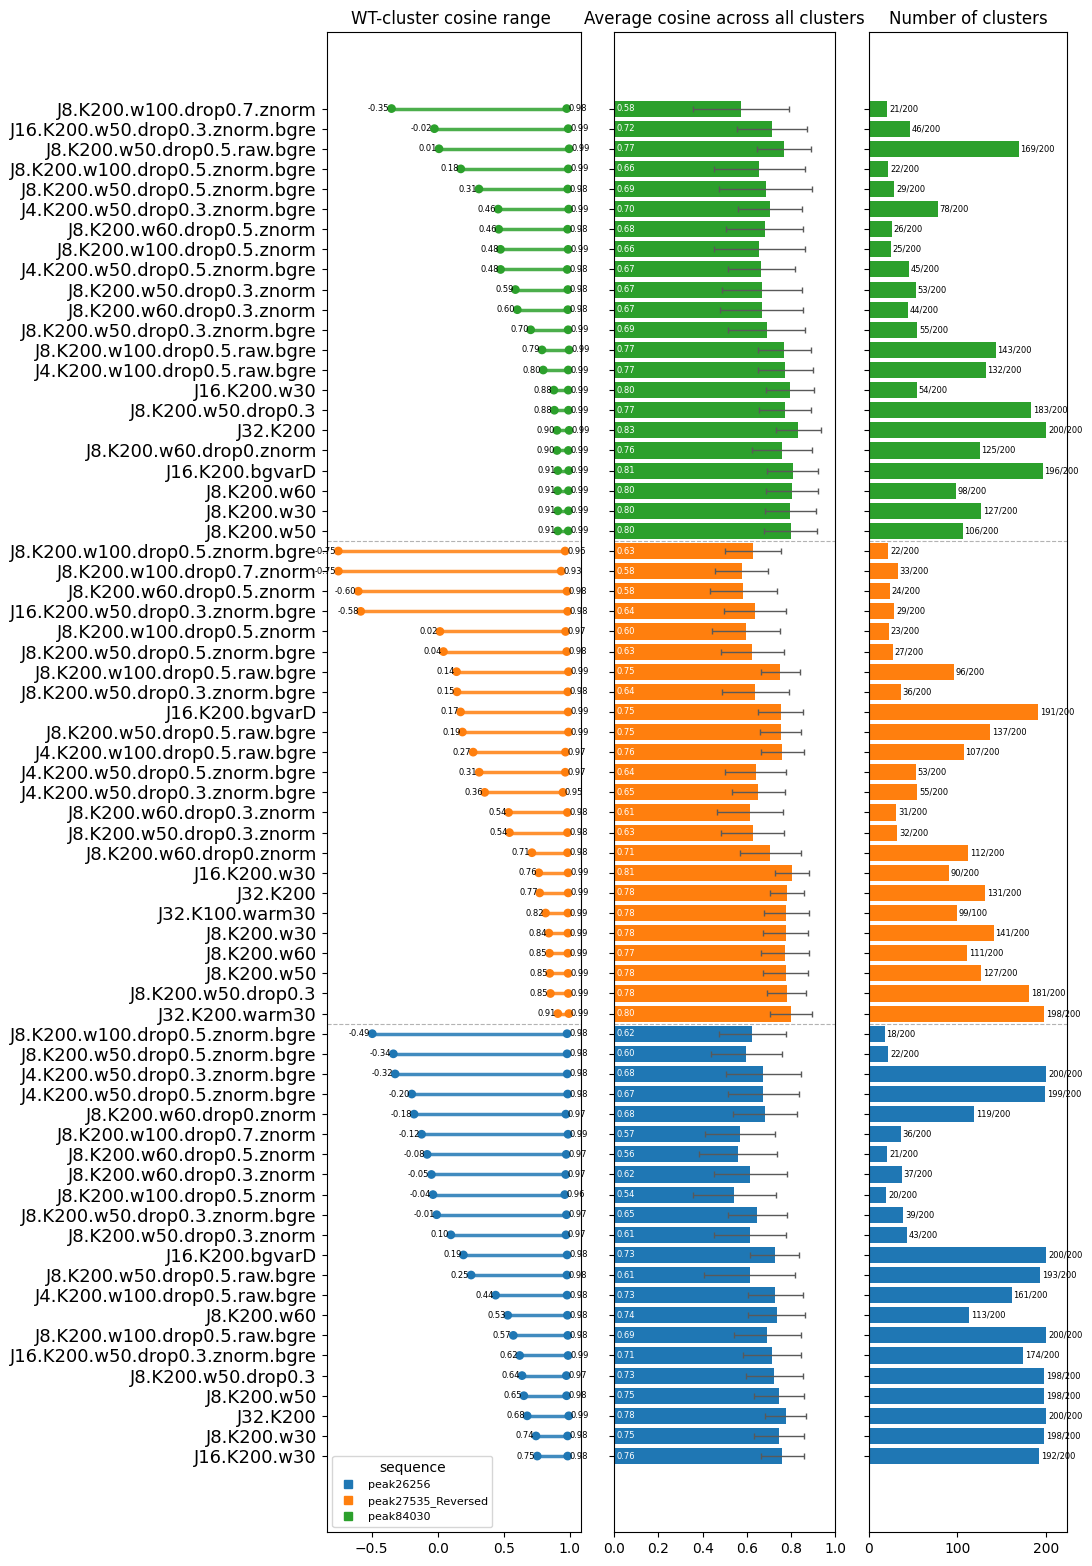

In [33]:
# ----- all three metrics side by side, sharing model names; grouped by sequence, increasing within -----
g = df.sort_values(["peak", "wt_cos_range"], ascending=[False, False]).reset_index(drop=True)  # seq blocks, ↑ range within
ypos = np.arange(len(g))[::-1]                                # first row at top
figh = max(4, 0.32 * len(g))
colors = list(g["color"])
NAME_FS = 13                                                  # <-- model-name font size (bump me)

fig, (axL, axM, axR) = plt.subplots(1, 3, figsize=(11, figh-6), sharey=True,
                                    gridspec_kw={"width_ratios": [1.15, 1, 0.9]})

# left: WT-cluster cosine range  [min, max]  (within-cluster spread of the WT cluster)
axL.hlines(ypos, g["wt_cos_min"], g["wt_cos_max"], color=colors, lw=2.5, alpha=0.85)
axL.scatter(g["wt_cos_min"], ypos, color=colors, s=28, zorder=3)
axL.scatter(g["wt_cos_max"], ypos, color=colors, s=28, zorder=3)
for y, lo, hi in zip(ypos, g["wt_cos_min"], g["wt_cos_max"]):
    axL.text(lo - 0.015, y, f"{lo:.2f}", va="center", ha="right", fontsize=6)
    axL.text(hi + 0.015, y, f"{hi:.2f}", va="center", ha="left",  fontsize=6)
axL.set_yticks(ypos); axL.set_yticklabels(g["short"], fontsize=NAME_FS)
axL.set_title("WT-cluster cosine range ")
axL.legend(handles=peak_handles, title="sequence", fontsize=8, loc="lower left")

# faint separators between sequence blocks (keep the groups visually distinct)
block_edges = np.where(g["peak"].values[1:] != g["peak"].values[:-1])[0]
for ax in (axL, axM, axR):
    for e in block_edges:
        ax.axhline(ypos[e] - 0.5, color="0.7", lw=0.8, ls="--")

# middle: average cosine across all clusters, +/- std of the per-cluster means
axM.barh(ypos, g["avg_cos_all_clusters"], xerr=g["avg_cos_std"], color=colors,
         error_kw=dict(ecolor="0.35", lw=1.0, capsize=2))
for y, v in zip(ypos, g["avg_cos_all_clusters"]):
    axM.text(0.01, y, f"{v:.2f}", va="center", ha="left", fontsize=6, color="white")
axM.set_xlim(0, 1)
axM.set_title("Average cosine across all clusters")

# right: number of surviving clusters (of initial K)
axR.barh(ypos, g["n_clusters"], color=colors)
for y, n, k in zip(ypos, g["n_clusters"], g["K"]):
    axR.text(n + 2, y, f"{n}/{k}", va="center", fontsize=6)
axR.set_xlim(0, g["K"].max() * 1.12)
axR.set_title("Number of clusters")

fig.tight_layout()
fig.savefig("results/vae_gmm_benchmark.png", dpi=300, bbox_inches="tight")   # save BEFORE show (show detaches/clears the figure)
plt.show()

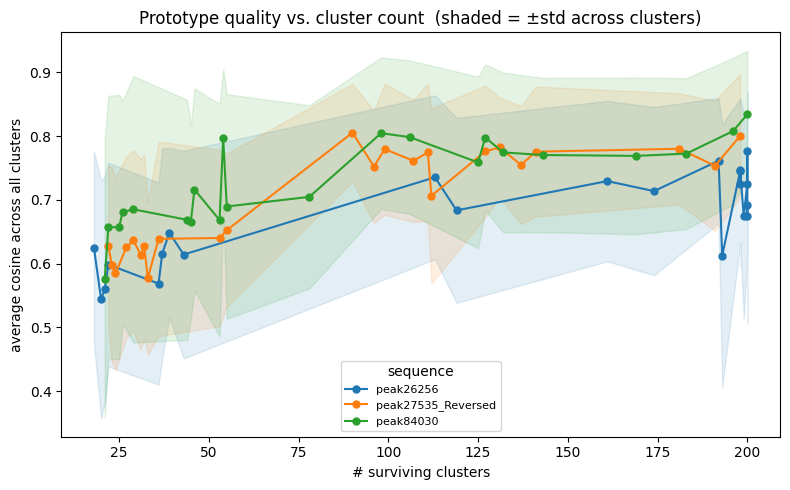

In [23]:
# ----- tradeoff line plot: average cosine (all clusters) vs number of clusters left, per sequence -----
# reads directly on the pruning/quality tradeoff: as more components survive, does mean
# prototype alignment hold up (good) or decay (over-splitting into weak clusters)?
fig, ax = plt.subplots(figsize=(8, 5))
for peak in peaks:
    d = df[df["peak"] == peak].sort_values("n_clusters")
    ax.plot(d["n_clusters"], d["avg_cos_all_clusters"], "-o", color=PEAK_COLOR[peak],
            ms=5, lw=1.5, label=peak)
    ax.fill_between(d["n_clusters"],
                    d["avg_cos_all_clusters"] - d["avg_cos_std"],
                    d["avg_cos_all_clusters"] + d["avg_cos_std"],
                    color=PEAK_COLOR[peak], alpha=0.12)
ax.set_xlabel("# surviving clusters")
ax.set_ylabel("average cosine across all clusters")
ax.set_title("Prototype quality vs. cluster count  (shaded = ±std across clusters)")
ax.legend(title="sequence", fontsize=8)
plt.tight_layout(); plt.show()

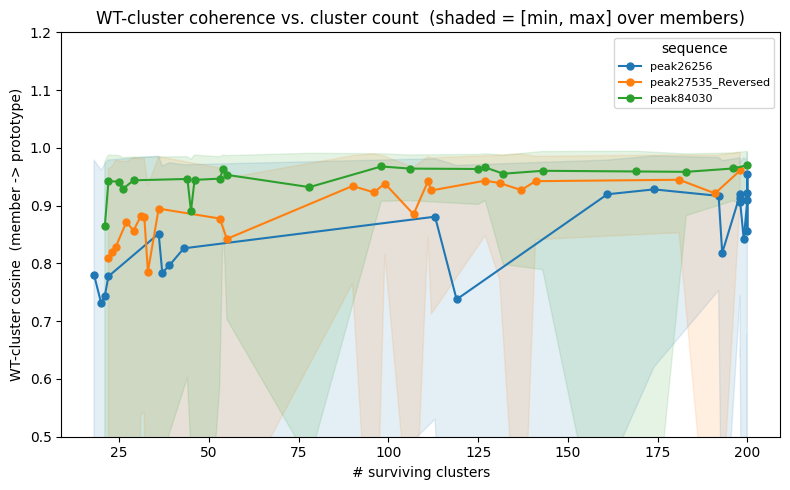

In [34]:
# ----- tradeoff line plot: WT-cluster cosine vs number of clusters left, per sequence -----
# does the WT (reference) cluster stay coherent as more components survive? line = WT-cluster
# mean member-to-prototype cosine; shaded band = [min, max] over the WT cluster's members.
fig, ax = plt.subplots(figsize=(8, 5))
for peak in peaks:
    d = df[df["peak"] == peak].sort_values("n_clusters")
    ax.plot(d["n_clusters"], d["wt_cos_mean"], "-o", color=PEAK_COLOR[peak],
            ms=5, lw=1.5, label=peak)
    ax.fill_between(d["n_clusters"], d["wt_cos_min"], d["wt_cos_max"],
                    color=PEAK_COLOR[peak], alpha=0.12)

ax.set_ylim(0.5, 1.2)
ax.set_xlabel("# surviving clusters")
ax.set_ylabel("WT-cluster cosine  (member -> prototype)")
ax.set_title("WT-cluster coherence vs. cluster count  (shaded = [min, max] over members)")
ax.legend(title="sequence", fontsize=8)
plt.tight_layout(); plt.show()

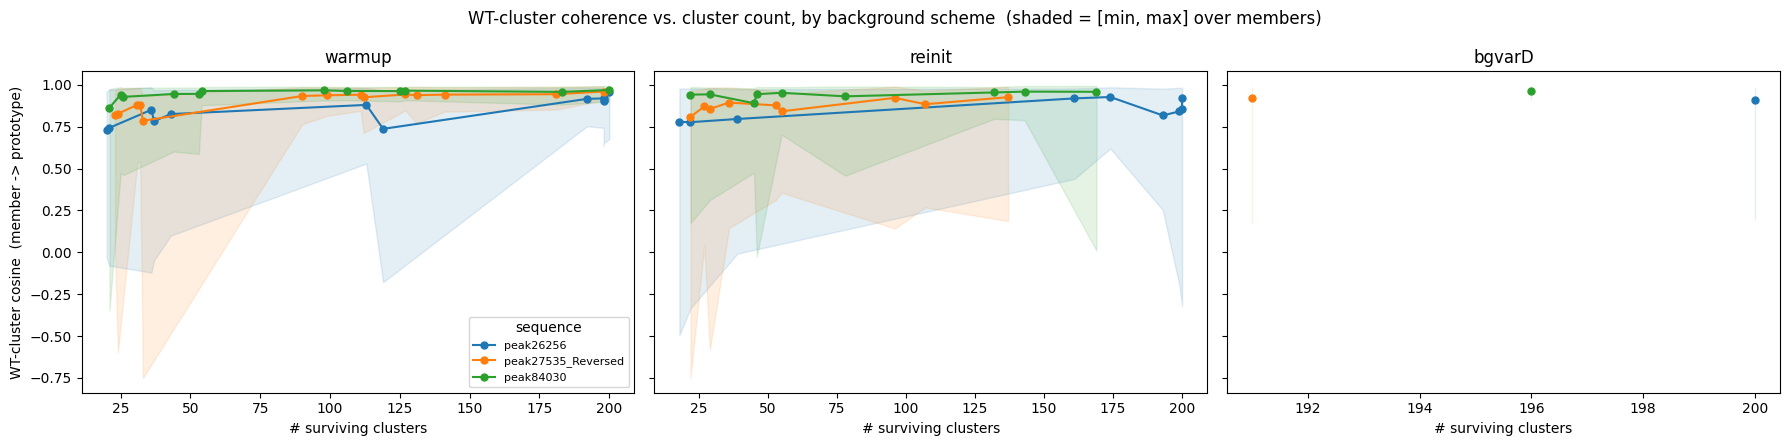

In [36]:
# ----- same WT-cluster tradeoff, faceted by background scheme -----
# line = WT-cluster mean member-to-prototype cosine; shaded band = [min, max] over members.
BG_TITLE = {"iso": "warmup", "bgre": "reinit", "bgvarD": "bgvarD"}   # display names for this plot
bgs = [b for b in ["iso", "bgre", "bgvarD"] if b in df["bg"].values]
fig, axes = plt.subplots(1, len(bgs), figsize=(6 * len(bgs), 4.5), sharey=True)
if len(bgs) == 1:
    axes = [axes]
for ax, bgm in zip(axes, bgs):
    for peak in peaks:
        d = df[(df["bg"] == bgm) & (df["peak"] == peak)].sort_values("n_clusters")
        if len(d) == 0:
            continue
        ax.plot(d["n_clusters"], d["wt_cos_mean"], "-o", color=PEAK_COLOR[peak],
                ms=5, lw=1.5, label=peak)
        ax.fill_between(d["n_clusters"], d["wt_cos_min"], d["wt_cos_max"],
                        color=PEAK_COLOR[peak], alpha=0.12)
    ax.set_title(BG_TITLE.get(bgm, bgm))
    ax.set_xlabel("# surviving clusters")
axes[0].set_ylabel("WT-cluster cosine  (member -> prototype)")
axes[0].legend(title="sequence", fontsize=8)
fig.suptitle("WT-cluster coherence vs. cluster count, by background scheme  (shaded = [min, max] over members)")
fig.tight_layout(); plt.show()

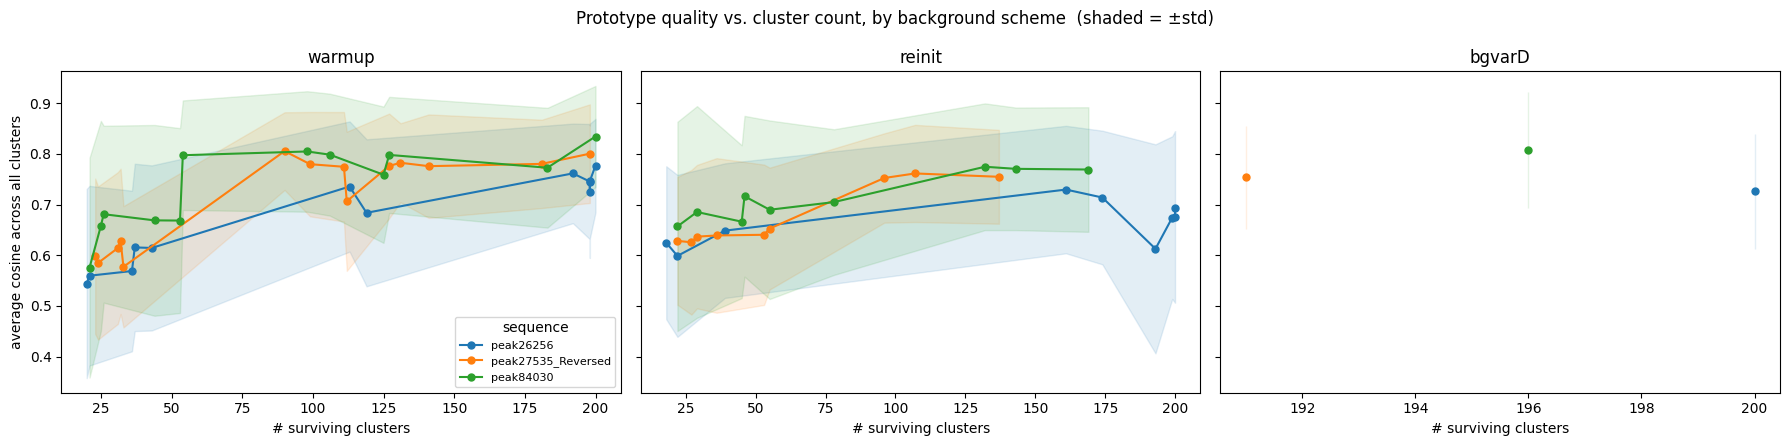

In [37]:
# ----- same tradeoff, faceted by background scheme -----
# isolates the background choice: within each bg mode, does the cluster-count / prototype
# quality relationship differ across sequences? (bgvarD may be a single point per sequence.)
BG_TITLE = {"iso": "warmup", "bgre": "reinit", "bgvarD": "bgvarD"}   # display names for this plot
bgs = [b for b in ["iso", "bgre", "bgvarD"] if b in df["bg"].values]
fig, axes = plt.subplots(1, len(bgs), figsize=(6 * len(bgs), 4.5), sharey=True)
if len(bgs) == 1:
    axes = [axes]
for ax, bgm in zip(axes, bgs):
    for peak in peaks:
        d = df[(df["bg"] == bgm) & (df["peak"] == peak)].sort_values("n_clusters")
        if len(d) == 0:
            continue
        ax.plot(d["n_clusters"], d["avg_cos_all_clusters"], "-o", color=PEAK_COLOR[peak],
                ms=5, lw=1.5, label=peak)
        ax.fill_between(d["n_clusters"],
                        d["avg_cos_all_clusters"] - d["avg_cos_std"],
                        d["avg_cos_all_clusters"] + d["avg_cos_std"],
                        color=PEAK_COLOR[peak], alpha=0.12)
    ax.set_title(BG_TITLE.get(bgm, bgm))
    ax.set_xlabel("# surviving clusters")
axes[0].set_ylabel("average cosine across all clusters")
axes[0].legend(title="sequence", fontsize=8)
fig.suptitle("Prototype quality vs. cluster count, by background scheme  (shaded = ±std)")
fig.tight_layout(); plt.show()